Using device: cuda
Model loaded successfully from best_model.pth!

Testing on random image: 34.png

📊 IoU Score for this image: 0.5032


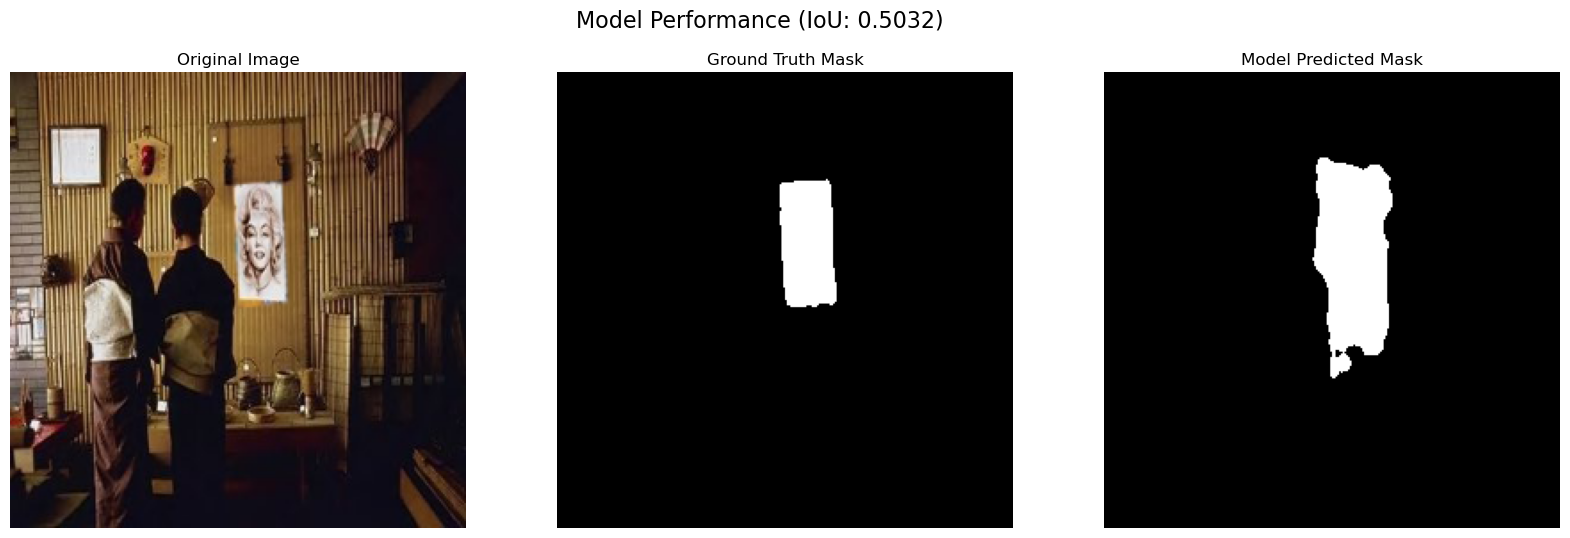

In [1]:
import os
import torch
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.metrics import iou_score, get_stats # <-- IMPORT get_stats
import matplotlib.pyplot as plt
import random

# ==============================
# 1. CONFIGURATION
# ==============================
PROCESSED_DIR = "processed_datasettttt"
MODEL_PATH = 'best_model.pth'

# Auto-detect device 
if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

# ==============================
# 2. LOAD THE TRAINED MODEL
# ==============================
try:
    # Re-define the model architecture exactly as you did for training
    model = smp.Unet(
        encoder_name="tu-efficientnet_b5",
        encoder_weights=None, # We are loading our own weights
        in_channels=5,
        classes=1,
        activation='sigmoid'
    )

    # Load the saved weights
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.to(DEVICE)
    model.eval() # Set model to evaluation mode
    print("Model loaded successfully from best_model.pth!")

except FileNotFoundError:
    print(f"Error: Model file not found at '{MODEL_PATH}'. Please make sure training is complete and the file exists.")
    # Exit if model can't be loaded
    exit()

# ==============================
# 3. DEFINE PREPROCESSING TRANSFORM
# ==============================
# This MUST be the same normalization as used in training
transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.5, 0.5), std=(0.229, 0.224, 0.225, 0.5, 0.5)),
    ToTensorV2(),
])

# ==============================
# 4. SELECT, PREDICT, AND EVALUATE
# ==============================
# Get a list of available images to test
image_names = os.listdir(os.path.join(PROCESSED_DIR, "images"))
if not image_names:
    print("Error: No images found in the 'processed_data/images' directory.")
    exit()

# Pick one random image
random_image_name = random.choice(image_names)
print(f"\nTesting on random image: {random_image_name}")

# --- Construct file paths ---
img_path = os.path.join(PROCESSED_DIR, "images", random_image_name)
mask_path = os.path.join(PROCESSED_DIR, "masks", random_image_name)
ela_path = os.path.join(PROCESSED_DIR, "ela_images", random_image_name)
hpf_path = os.path.join(PROCESSED_DIR, "hpf_images", random_image_name)

# --- Load all necessary data ---
original_image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
ground_truth_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
ela = cv2.imread(ela_path, cv2.IMREAD_GRAYSCALE)
hpf = cv2.imread(hpf_path, cv2.IMREAD_GRAYSCALE)

# --- Preprocess the image for the model ---
combined_input_image = np.dstack([original_image, ela, hpf])
transformed = transform(image=combined_input_image)
input_tensor = transformed['image'].unsqueeze(0).to(DEVICE) # Add batch dimension

# --- Get the model's prediction ---
with torch.no_grad():
    output_tensor = model(input_tensor)

# --- Calculate the IoU Score ---
# Binarize the model's prediction (convert probabilities to 0s and 1s)
pred_binary_tensor = (output_tensor > 0.5).long()

# Convert the ground truth numpy mask to a tensor of the same type
gt_tensor = torch.from_numpy(ground_truth_mask / 255.0).unsqueeze(0).unsqueeze(0).long().to(DEVICE)

# NEW STEP: Calculate tp, fp, fn, tn
tp, fp, fn, tn = get_stats(pred_binary_tensor, gt_tensor, mode='binary')

# NEW STEP: Pass the stats to iou_score
iou = iou_score(tp, fp, fn, tn, reduction='micro')
print(f"\n📊 IoU Score for this image: {iou.item():.4f}")

# --- Post-process for visualization ---
predicted_mask = pred_binary_tensor.squeeze().cpu().numpy().astype(np.uint8)

# --- Visualize the results ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Model Performance (IoU: {iou.item():.4f})", fontsize=16)

ax1.imshow(original_image)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(ground_truth_mask, cmap='gray')
ax2.set_title('Ground Truth Mask')
ax2.axis('off')

ax3.imshow(predicted_mask, cmap='gray')
ax3.set_title('Model Predicted Mask')
ax3.axis('off')

plt.show()

In [2]:
import os
import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.metrics import iou_score, get_stats, accuracy # <-- ADD 'accuracy'
from tqdm import tqdm

# ==============================
# 1. CONFIGURATION
# ==============================
PROCESSED_DIR = "processed_datasettttt"
MODEL_PATH = 'best_model.pth'
BATCH_SIZE = 16

# Auto-detect device
if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")
IMG_IDS = os.listdir(os.path.join(PROCESSED_DIR, "images"))
_, VAL_IDS = train_test_split(IMG_IDS, test_size=0.2, random_state=42)

# ==============================
# 2. DATASET and DATALOADER
# ==============================
class ForgeryDataset(Dataset):
    def __init__(self, image_ids, directory, transform=None):
        self.image_ids = image_ids
        self.directory = directory
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        # This part is simplified as it's the same as before
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.directory, "images", img_name)
        mask_path = os.path.join(self.directory, "masks", img_name)
        ela_path = os.path.join(self.directory, "ela_images", img_name)
        hpf_path = os.path.join(self.directory, "hpf_images", img_name)
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        ela = cv2.imread(ela_path, cv2.IMREAD_GRAYSCALE)
        hpf = cv2.imread(hpf_path, cv2.IMREAD_GRAYSCALE)
        combined_image = np.dstack([image, ela, hpf])
        mask = (mask / 255.0).astype(np.float32)
        if self.transform:
            augmented = self.transform(image=combined_image, mask=mask)
            combined_image = augmented['image']
            mask = augmented['mask']
        return combined_image, mask

eval_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.5, 0.5), std=(0.229, 0.224, 0.225, 0.5, 0.5)),
    ToTensorV2(),
])

val_dataset = ForgeryDataset(VAL_IDS, PROCESSED_DIR, transform=eval_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Evaluating on {len(val_dataset)} validation samples...")

# ==============================
# 3. LOAD THE TRAINED MODEL
# ==============================
try:
    model = smp.Unet(
        encoder_name="tu-efficientnet_b5", encoder_weights=None, in_channels=5, classes=1, activation='sigmoid'
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.to(DEVICE)
    model.eval()
    print("Model loaded successfully!")
except FileNotFoundError:
    print(f"Error: Model file not found at '{MODEL_PATH}'.")
    exit()

# ==============================
# 4. EVALUATION LOOP
# ==============================
total_iou = 0.0
total_accuracy = 0.0
loop = tqdm(val_loader, desc="Evaluating")

with torch.no_grad():
    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE).unsqueeze(1)
        
        outputs = model(images)
        
        pred_binary = (outputs > 0.5).long()
        gt_binary = (masks > 0.5).long()
        
        tp, fp, fn, tn = get_stats(pred_binary, gt_binary, mode='binary')
        
        # Calculate IoU for the batch
        batch_iou = iou_score(tp, fp, fn, tn, reduction='micro')
        total_iou += batch_iou.item()
        
        # Calculate Pixel Accuracy for the batch
        batch_accuracy = accuracy(tp, fp, fn, tn, reduction='micro')
        total_accuracy += batch_accuracy.item()
        
# --- Calculate and Print Final Scores ---
mean_iou = total_iou / len(val_loader)
mean_accuracy = total_accuracy / len(val_loader)

print("\n" + "="*45)
print("          Model Evaluation Results")
print("="*45)
#print(f"📊 Mean IoU Score     : {mean_iou:.4f} ({mean_iou * 100:.2f}%)")
print(f"🎯 Pixel Accuracy     : {mean_accuracy:.4f} ({mean_accuracy * 100:.2f}%)")
print("="*45)

Using device: cuda
Evaluating on 1025 validation samples...
Model loaded successfully!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 65/65 [00:16<00:00,  4.05it/s]


          Model Evaluation Results
🎯 Pixel Accuracy     : 0.8920 (89.20%)


Using device: cuda
Evaluating on 1025 validation samples...
Model loaded successfully!


Evaluating Images: 100%|███████████████████████████████████████████████████████████████| 65/65 [00:13<00:00,  4.88it/s]
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13936\975254488.py:143: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.9])



--- Displaying Best and Worst Predictions ---


D:\Users\LENOVO\Downloads\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


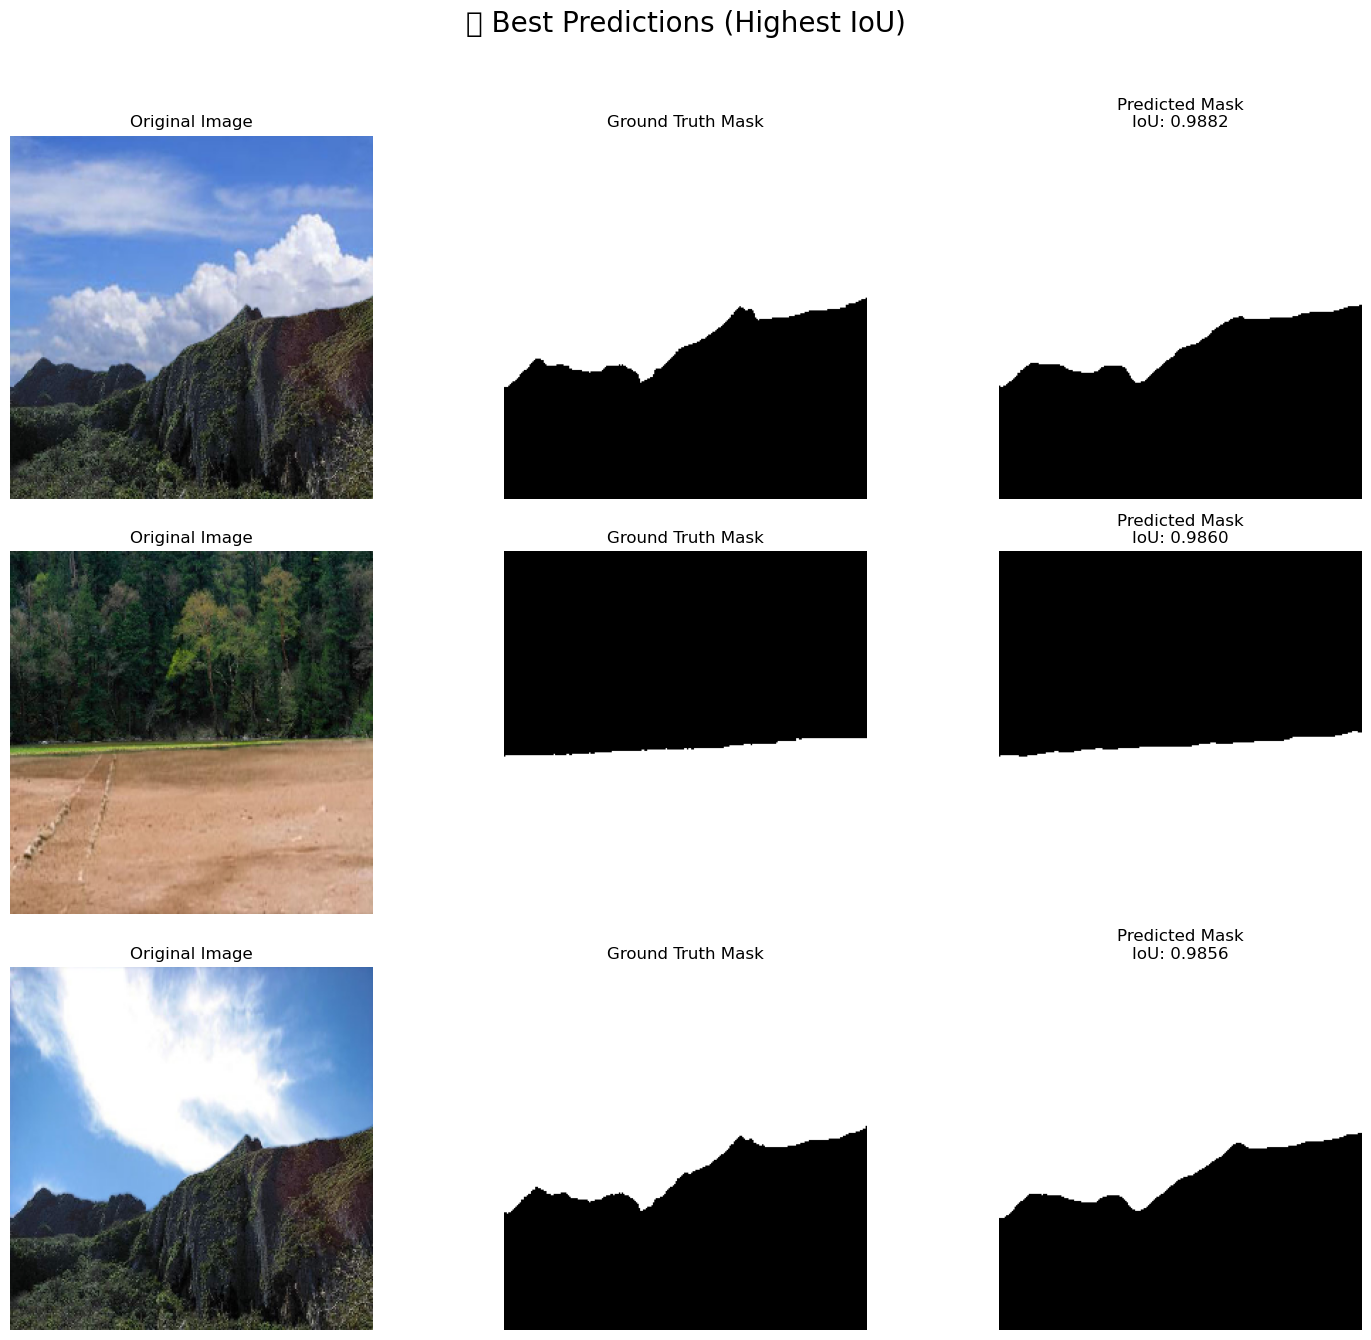

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13936\975254488.py:143: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.9])
D:\Users\LENOVO\Downloads\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128148 (\N{BROKEN HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


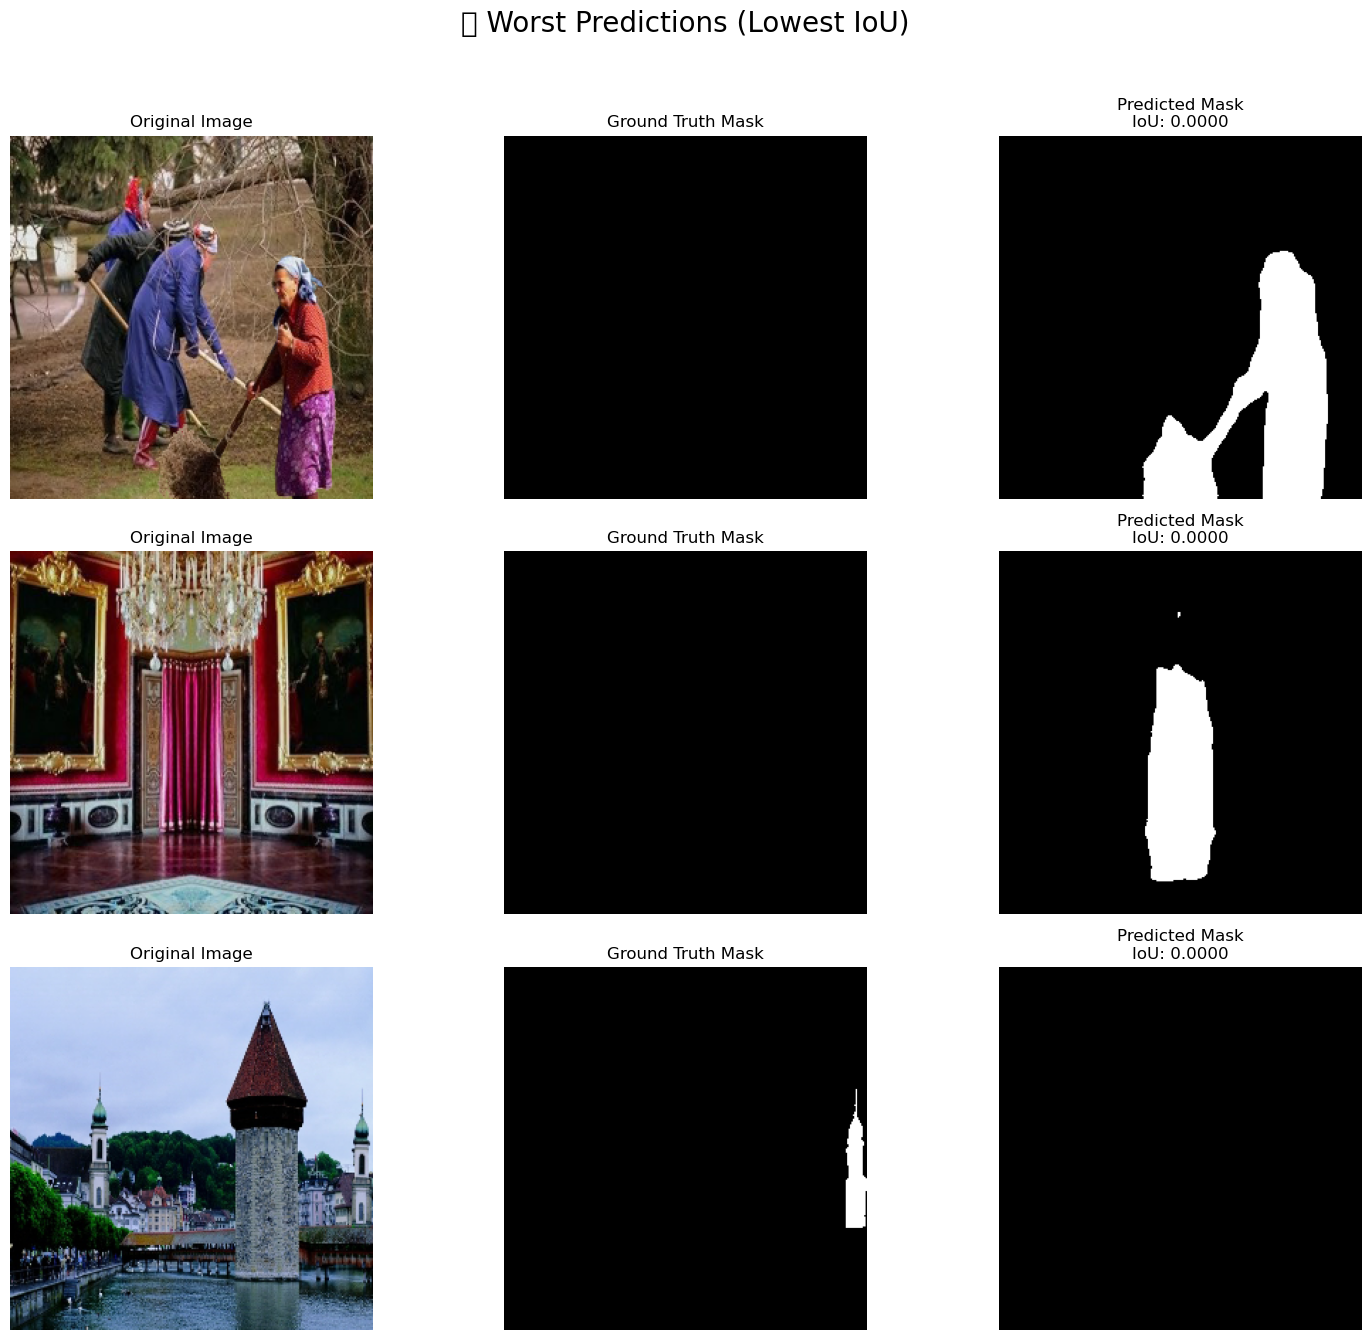

In [3]:
import os
import cv2
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.metrics import iou_score, get_stats
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==============================
# 1. CONFIGURATION
# ==============================
PROCESSED_DIR = "processed_datasettttt"
MODEL_PATH = 'best_model.pth'
BATCH_SIZE = 16

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")

# Get list of image IDs and create a validation set
IMG_IDS = [f for f in os.listdir(os.path.join(PROCESSED_DIR, "images")) if not f.startswith('.')]
_, VAL_IDS = train_test_split(IMG_IDS, test_size=0.2, random_state=42)

# ==============================
# 2. DATASET and DATALOADER
# ==============================
class ForgeryDataset(Dataset):
    def __init__(self, image_ids, directory, transform=None):
        self.image_ids = image_ids
        self.directory = directory
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.directory, "images", img_name)
        mask_path = os.path.join(self.directory, "masks", img_name)
        ela_path = os.path.join(self.directory, "ela_images", img_name)
        hpf_path = os.path.join(self.directory, "hpf_images", img_name)
        
        original_image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        ela = cv2.imread(ela_path, cv2.IMREAD_GRAYSCALE)
        hpf = cv2.imread(hpf_path, cv2.IMREAD_GRAYSCALE)
        
        combined_image = np.dstack([original_image, ela, hpf])
        
        if self.transform:
            augmented = self.transform(image=combined_image, mask=mask)
            combined_image_tensor = augmented['image']
            mask_tensor = (augmented['mask'] / 255.0).float()
        
        return original_image, combined_image_tensor, mask_tensor

eval_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.5, 0.5), std=(0.229, 0.224, 0.225, 0.5, 0.5)),
    ToTensorV2(),
])

val_dataset = ForgeryDataset(VAL_IDS, PROCESSED_DIR, transform=eval_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Evaluating on {len(val_dataset)} validation samples...")

# ==============================
# 3. LOAD THE TRAINED MODEL
# ==============================
try:
    model = smp.Unet(
        encoder_name="tu-efficientnet_b5", encoder_weights=None, in_channels=5, classes=1, activation='sigmoid'
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.to(DEVICE)
    model.eval()
    print("Model loaded successfully!")
except FileNotFoundError:
    print(f"Error: Model file not found at '{MODEL_PATH}'.")
    exit()

# ==============================
# 4. EVALUATE AND STORE RESULTS
# ==============================
results = []
loop = tqdm(val_loader, desc="Evaluating Images")

with torch.no_grad():
    for original_images, input_tensors, gt_masks in loop:
        input_tensors = input_tensors.to(DEVICE)
        gt_masks = gt_masks.to(DEVICE).unsqueeze(1)
        
        output_tensors = model(input_tensors)
        
        # Calculate IoU for each image in the batch
        for i in range(input_tensors.size(0)):
            output = output_tensors[i]
            gt = gt_masks[i]
            
            pred_binary = (output > 0.5).long()
            gt_binary = (gt > 0.5).long()
            
            tp, fp, fn, tn = get_stats(pred_binary, gt_binary, mode='binary')
            iou = iou_score(tp, fp, fn, tn, reduction='micro').item()
            
            results.append({
                "original": original_images[i].numpy().astype(np.uint8),
                "ground_truth": gt.squeeze().cpu().numpy(),
                "predicted": pred_binary.squeeze().cpu().numpy(),
                "iou": iou
            })

# ==============================
# 5. SORT AND VISUALIZE RESULTS
# ==============================
# Sort results by IoU score
results.sort(key=lambda x: x['iou'], reverse=True)

def display_results(results_subset, title):
    fig, axes = plt.subplots(len(results_subset), 3, figsize=(15, len(results_subset) * 5))
    fig.suptitle(title, fontsize=20, y=0.92)
    
    for i, res in enumerate(results_subset):
        axes[i, 0].imshow(res['original'])
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(res['ground_truth'], cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(res['predicted'], cmap='gray')
        axes[i, 2].set_title(f"Predicted Mask\nIoU: {res['iou']:.4f}")
        axes[i, 2].axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

# Display the 3 best and 3 worst results
print("\n--- Displaying Best and Worst Predictions ---")
display_results(results[:3], "🏆 Best Predictions (Highest IoU)")
display_results(results[-3:], "💔 Worst Predictions (Lowest IoU)")